In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter


In [2]:
data_dir = '/home/reilly/Desktop/Toroidal_topology_grid_cell_data/rat_q_grid_modules_1_2.npz'
# data_dir = '/home/dabin/data/Toroidal_topology_grid_cell_data/rat_q_grid_modules_1_2.npz'
data = np.load(data_dir, allow_pickle=True)
# open the npz file and explore its contents
data.files

['spikes_mod1', 'spikes_mod2', 'x', 'y', 't', 'z', 'azimuth']

In [3]:
data['t']

array([ 9576.01,  9576.02,  9576.03, ..., 31222.97, 31222.98, 31222.99],
      shape=(2164699,))

In [4]:
for key in data.files:
    print(f"{key}: {data[key].shape}")

spikes_mod1: ()
spikes_mod2: ()
x: (2164699,)
y: (2164699,)
t: (2164699,)
z: (2164699,)
azimuth: (2164699,)


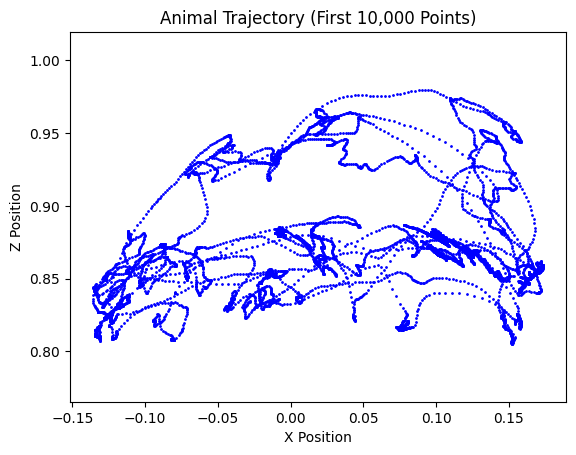

In [5]:
plt.scatter(data['x'][:10_000], data['z'][:10_000], c='blue', s=1)
plt.xlabel('X Position')
plt.ylabel('Z Position')
plt.title('Animal Trajectory (First 10,000 Points)')
plt.axis('equal')
plt.show()

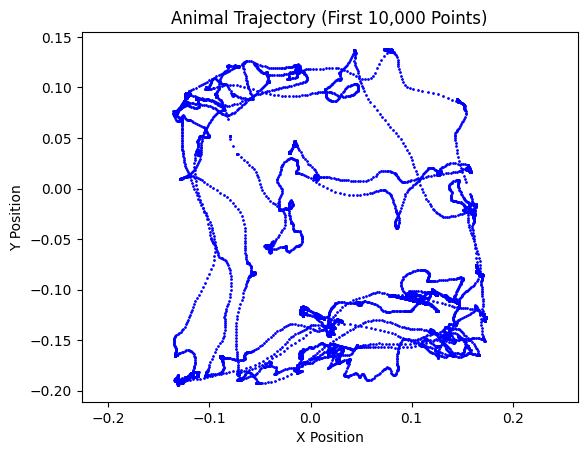

In [6]:
plt.scatter(data['x'][:10_000], data['y'][:10_000], c='blue', s=1)
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('Animal Trajectory (First 10,000 Points)')
plt.axis('equal')
plt.show()

In [7]:
start = 27_826
end = 31_223
x, y, t = data['x'], data['y'], data['t']
x = x[(t >= start) & (t <= end)]
y = y[(t >= start) & (t <= end)]
t = t[(t >= start) & (t <= end)]
spike_times = data['spikes_mod1']
spike_times = spike_times.item()
spike_times = {neuron: times[(times >= start) & (times <= end)] for neuron, times in spike_times.items()} # filter spikes to be within start and end time
spike_times = {neuron: np.round(times, 2) for neuron, times in spike_times.items()} # round spike times to 2 decimal places (same as t)
# convert dict of arrays to list of arrays
spike_times = list(spike_times.values())
# convert spike times and t to integers, starting from 0
spike_times = [(times * 100).astype(int) - start * 100 for times in spike_times]
t = (t * 100).astype(int) - start * 100
# disregard any spike times that are outside the range of t
spike_times = [times[(times >= t[0]) & (times <= t[-1])] for times in spike_times]
# rescale x and y to be between -1 and 1
wall_val = 0.75
x = x / wall_val
y = y / wall_val
# get frequently used variables
n_cells = len(spike_times)
n_timepoints = len(t)
print(f'Number of cells: {n_cells}, Number of timepoints: {n_timepoints}')

Number of cells: 97, Number of timepoints: 339700


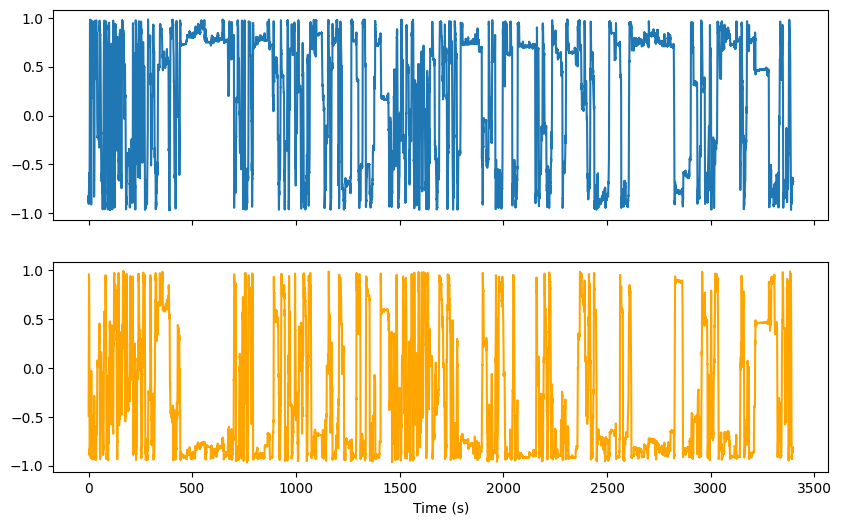

In [8]:
# plot position over time
plt.subplots(2, 1, figsize=(10, 6), sharex=True)
plt.subplot(2, 1, 1)
plt.plot(t / 100, x, label='X Position')
plt.subplot(2, 1, 2)
plt.plot(t / 100, y, label='Y Position', color='orange')
plt.xlabel('Time (s)')
plt.show()


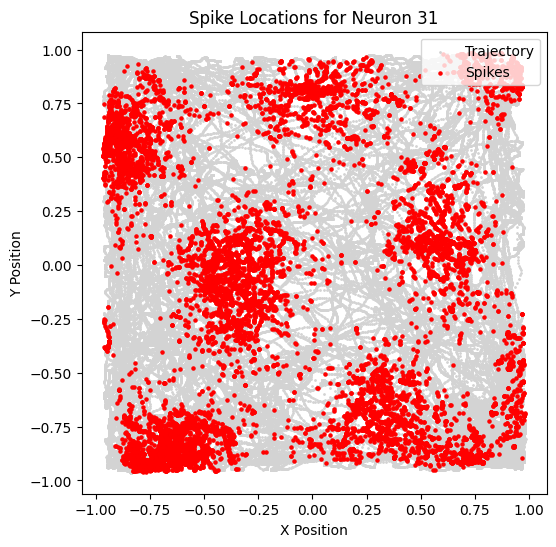

In [27]:
# plot heatmap of spikes for a particular neuron
cell_no = np.random.randint(0, n_cells)
x_spikes, y_spikes = x[spike_times[cell_no]], y[spike_times[cell_no]]
plt.figure(figsize=(6, 6))
plt.scatter(x, y, c='lightgrey', s=1, label='Trajectory')
plt.scatter(x_spikes, y_spikes, c='red', s=5, label='Spikes')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title(f'Spike Locations for Neuron {cell_no}')
plt.axis('equal')
plt.legend(loc='upper right')
plt.show()

In [ ]:
# # build response matrix
# R = np.zeros((n_cells, n_timepoints // 10))
# for t in range(n_timepoints):
#     for c in range(n_cells):
#         if t in spike_times[c]:
#             R[c, t // 10] += 1  # count spikes in 100 ms bins
#     if t % 1000 == 0:
#         print(f'Processed timepoint {t}/{n_timepoints}')

# plt.imshow(R, aspect='auto', interpolation='none', vmin=0, vmax=5)
# plt.colorbar(label='Spike Count')
# plt.xlabel('Time Bins (100 ms)')
# plt.ylabel('Neurons')
# plt.title('Neural Response Matrix (First 50 Neurons)')
# plt.show()

In [17]:
n_bins = 65
occupancy = np.histogram2d(x, y, bins=n_bins, range=[[-1, 1], [-1, 1]])[0]

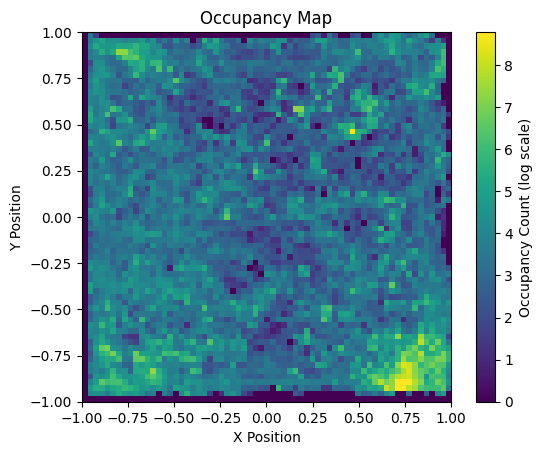

In [18]:
plt.imshow(np.log(occupancy.T + 1), origin='lower', extent=[-1, 1, -1, 1])
plt.colorbar(label='Occupancy Count (log scale)')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('Occupancy Map')
plt.show()

In [195]:
# get spike count map for each neuron
spike_map = np.zeros((n_cells, n_bins, n_bins))
occupancy = np.histogram2d(x, y, bins=n_bins, range=[[-1, 1], [-1, 1]])[0]
for c in range(n_cells):
    x_spikes, y_spikes = x[spike_times[c]], y[spike_times[c]]
    spike_map[c], _, _ = np.histogram2d(x_spikes, y_spikes, bins=n_bins, range=[[-1, 1], [-1, 1]])

# smooth spike maps and occupancy map
sigma = 1
occupancy_smooth = gaussian_filter(occupancy, sigma=sigma)
spike_map_smooth = np.array([gaussian_filter(spike_map[c], sigma=sigma) for c in range(n_cells)])

rate_map = spike_map_smooth / (occupancy_smooth + 1e-6)  # avoid division by zero

In [199]:
spike_map1 = np.zeros((n_cells, n_bins, n_bins))
occupancy1 = np.zeros((n_bins, n_bins))
spike_map2 = np.zeros((n_cells, n_bins, n_bins))
occupancy2 = np.zeros((n_bins, n_bins))
t_half = n_timepoints // 2
for c in range(n_cells):
    x_spikes1, y_spikes1 = x[spike_times[c][spike_times[c] < t_half]], y[spike_times[c][spike_times[c] < t_half]]
    spike_map1[c], _, _ = np.histogram2d(x_spikes1, y_spikes1, bins=n_bins, range=[[-1, 1], [-1, 1]])
    x_spikes2, y_spikes2 = x[spike_times[c][spike_times[c] >= t_half]], y[spike_times[c][spike_times[c] >= t_half]]
    spike_map2[c], _, _ = np.histogram2d(x_spikes2, y_spikes2, bins=n_bins, range=[[-1, 1], [-1, 1]])
occupancy1 = np.histogram2d(x[t < t_half], y[t < t_half], bins=n_bins, range=[[-1, 1], [-1, 1]])[0]
occupancy2 = np.histogram2d(x[t >= t_half], y[t >= t_half], bins=n_bins, range=[[-1, 1], [-1, 1]])[0]

In [200]:
def compute_rate_map(spike_map, occupancy, sigma):
    occupancy_smooth = gaussian_filter(occupancy, sigma=sigma)
    spike_map_smooth = np.array([gaussian_filter(spike_map[c], sigma=sigma) for c in range(n_cells)])
    rate_map = spike_map_smooth / (occupancy_smooth + 1e-6)  # avoid division by zero
    return rate_map

def loss(rate_map1, rate_map2):
    return np.abs(rate_map1 - rate_map2).mean()

In [221]:
# Choose optimal sigma for smoothing by (naive) bracketed search
n_iter = 10
sigma_min = 0.1
sigma_max = 5.0

def eval_loss(sigma):
    rate_map1_smooth = compute_rate_map(spike_map1, occupancy1, sigma)
    return loss(rate_map1_smooth, rate_map2)

rate_map2 = spike_map2 / (occupancy2 + 1e-6)

loss_min = eval_loss(sigma_min)
loss_max = eval_loss(sigma_max)

for i in range(n_iter):
    sigma_mid = (sigma_min + sigma_max) / 2
    loss_mid = eval_loss(sigma_mid)

    # Keep (sigma_min, loss_min) and (sigma_max, loss_max) consistent
    if loss_mid < loss_min and loss_mid < loss_max:
        # mid is better than both ends: keep mid, drop the worse end
        if loss_min > loss_max:
            sigma_min, loss_min = sigma_mid, loss_mid
        else:
            sigma_max, loss_max = sigma_mid, loss_mid
    else:
        # mid is not better than both: drop the worse end, keep the better end + mid
        if loss_min > loss_max:
            sigma_min, loss_min = sigma_mid, loss_mid
        else:
            sigma_max, loss_max = sigma_mid, loss_mid

    print(f"Iteration {i+1}, sigma_mid: {sigma_mid:.6g}, loss_mid: {loss_mid:.6g}, "
          f"bracket=({sigma_min:.6g},{sigma_max:.6g}) losses=({loss_min:.6g},{loss_max:.6g})")

optimal_sigma = sigma_min if loss_min < loss_max else sigma_max


Iteration 1, sigma_mid: 2.55, loss_mid: 0.0389346, bracket=(2.55,5) losses=(0.0389346,0.0404619)
Iteration 2, sigma_mid: 3.775, loss_mid: 0.039619, bracket=(2.55,3.775) losses=(0.0389346,0.039619)
Iteration 3, sigma_mid: 3.1625, loss_mid: 0.0392257, bracket=(2.55,3.1625) losses=(0.0389346,0.0392257)
Iteration 4, sigma_mid: 2.85625, loss_mid: 0.0390608, bracket=(2.55,2.85625) losses=(0.0389346,0.0390608)
Iteration 5, sigma_mid: 2.70312, loss_mid: 0.038992, bracket=(2.55,2.70312) losses=(0.0389346,0.038992)
Iteration 6, sigma_mid: 2.62656, loss_mid: 0.0389617, bracket=(2.55,2.62656) losses=(0.0389346,0.0389617)
Iteration 7, sigma_mid: 2.58828, loss_mid: 0.0389476, bracket=(2.55,2.58828) losses=(0.0389346,0.0389476)
Iteration 8, sigma_mid: 2.56914, loss_mid: 0.038941, bracket=(2.55,2.56914) losses=(0.0389346,0.038941)
Iteration 9, sigma_mid: 2.55957, loss_mid: 0.0389378, bracket=(2.55,2.55957) losses=(0.0389346,0.0389378)
Iteration 10, sigma_mid: 2.55479, loss_mid: 0.0389362, bracket=(2.5

In [243]:
spike_map = np.zeros((n_cells, n_bins, n_bins))
occupancy = np.zeros((n_bins, n_bins))
for c in range(n_cells):
    x_spikes, y_spikes = x[spike_times[c]], y[spike_times[c]]
    spike_map[c], _, _ = np.histogram2d(x_spikes, y_spikes, bins=n_bins, range=[[-1, 1], [-1, 1]])
occupancy = np.histogram2d(x, y, bins=n_bins, range=[[-1, 1], [-1, 1]])[0]
rate_map = compute_rate_map(spike_map, occupancy, optimal_sigma)

# get rate_maps for first and second half of the data
rate_map1 = compute_rate_map(spike_map1, occupancy1, optimal_sigma)
rate_map2 = compute_rate_map(spike_map2, occupancy2, optimal_sigma)    

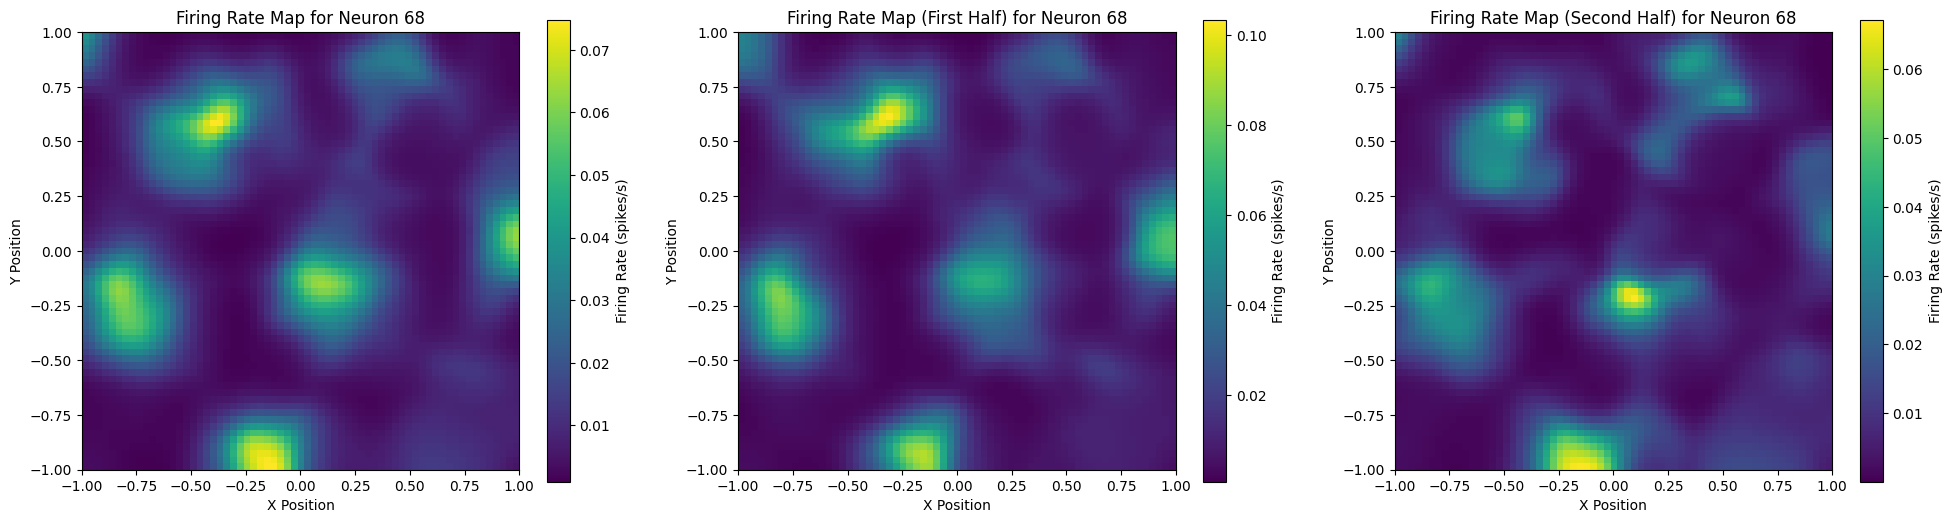

In [260]:
# choose a random cell to plot
plt.subplots(1, 3, figsize=(24, 6))
plt.subplot(1, 3, 1)
cell_no = np.random.randint(0, n_cells)
plt.imshow(rate_map[cell_no].T, origin='lower', extent=[-1, 1, -1, 1])
plt.colorbar(label='Firing Rate (spikes/s)')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title(f'Firing Rate Map for Neuron {cell_no}')
plt.subplot(1, 3, 2)
plt.imshow(rate_map1[cell_no].T, origin='lower', extent=[-1, 1, -1, 1])
plt.colorbar(label='Firing Rate (spikes/s)')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title(f'Firing Rate Map (First Half) for Neuron {cell_no}')
plt.subplot(1, 3, 3)
plt.imshow(rate_map2[cell_no].T, origin='lower', extent=[-1, 1, -1, 1])
plt.colorbar(label='Firing Rate (spikes/s)')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title(f'Firing Rate Map (Second Half) for Neuron {cell_no}')
plt.show()

In [71]:
# test data_parser functions 
from experiments.grid_cells.data_parser import compute_rate_map, load_and_process_data

result = load_and_process_data('/home/dabin/data/Toroidal_topology_grid_cell_data/rat_q_grid_modules_1_2.npz', filter_grid_cells=True)
predictors = result['predictors']
response = result['response']
rate_maps = result['rate_maps']
position_data = result['position_data']
n_spatial_bins = position_data['n_spatial_bins']

x = predictors['x']
y = predictors['y']
n_cells = response.shape[0]


Spatial binning: 50x50 bins of 3.0cm for 150cm arena
Available features in data file: ['x', 'y', 'z', 'azimuth']
Time discretisation: 339700 bins of 10 ms from 27826s to 31223s
Speed filtering: excluding 140729/339700 bins below 2.5 cm/s
Loaded 97 neurons (from 97 total) with >= 100 spikes
Final data shape: 97 neurons x 198971 time bins
Subsampled from 198971 to 5000 time bins


In [72]:
x.shape, y.shape, response.shape, rate_maps.shape, n_cells

((97, 5000), (97, 5000), (97, 5000), (97, 50, 50), 97)

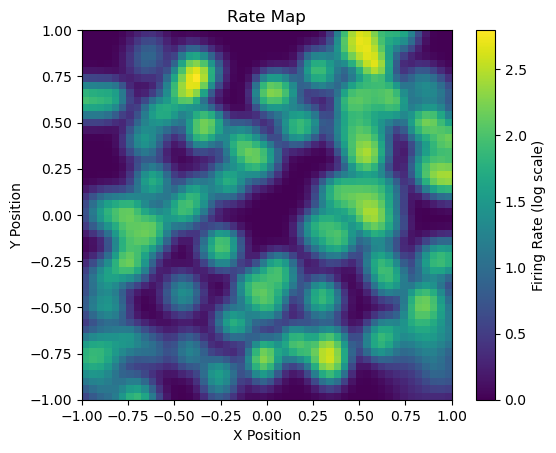

In [96]:

# visualise rate map of a sample cell 
cell_idx = np.random.randint(0, n_cells-1)
plt.imshow(np.log(rate_maps[cell_idx].T + 1), origin='lower', extent=[-1, 1, -1, 1])
plt.colorbar(label='Firing Rate (log scale)')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('Rate Map')
plt.show()


In [ ]:
def grid_rate_cosine(
    x, y,
    lam=0.5,            # grid spacing (same units as x,y)
    theta=0.0,          # orientation (radians)
    phi_x = 0.0,        # phase offset x0
    phi_y = 0.0,        # phase offset y0
    b=0.0,              # baseline
    A=1.0               # amplitude
):
    """
    Model (1): r(x,y) = b + A * sum_{k=0}^2 cos(q * u_k^T ([x,y]-phi)),
    with q = 4*pi/(sqrt(3)*lam) and u_k 60deg apart.

    x,y can be scalars or numpy arrays (broadcasting supported).
    Returns r with the broadcasted shape of x and y.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    x0, y0 = phi_x, phi_y

    # wave number chosen so that the resulting lattice spacing is lam
    q = 4.0 * np.pi / (np.sqrt(3.0) * lam)

    # three directions 60 degrees apart
    angles = theta + 2.0 * np.pi * np.arange(3) / 3.0
    ux = np.cos(angles)
    uy = np.sin(angles)

    dx = x - x0
    dy = y - y0

    # sum of three plane waves
    s = 0.0
    for k in range(3):
        proj = ux[k] * dx + uy[k] * dy
        s = s + np.cos(q * proj)

    return b + A * s


def grid_rate_gaussian_lattice(
    x, y,
    scale=0.5,          # lattice spacing
    theta=0.0,          # orientation (radians)
    phi_x = 0.0,        # phase offset x0
    phi_y = 0.0,        # phase offset y0
    b=0.0,              # baseline
    a=1.0,              # bump amplitude per field
    sigma=0.08,         # bump width
    extent=None,        # (xmin, xmax, ymin, ymax); if None, inferred from x,y
    margin=2.0          # add this many *lam beyond extent when tiling fields
):
    """
    Model (3): sum of Gaussians centered on a hexagonal lattice.

    Implementation detail: we approximate the infinite lattice by summing
    centers covering a bounding box (extent) expanded by margin*lam.

    x,y can be scalars or numpy arrays. Returns r with broadcasted shape.

    extent: specify in the same coordinate system as x,y. If you're evaluating
    on a grid over your arena, pass the arena bounds for reproducibility.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    x0, y0 = phi_x, phi_y

    # infer extent from evaluation points if not provided
    if extent is None:
        xmin = float(np.nanmin(x))
        xmax = float(np.nanmax(x))
        ymin = float(np.nanmin(y))
        ymax = float(np.nanmax(y))
    else:
        xmin, xmax, ymin, ymax = map(float, extent)

    # expand box to include nearby lattice points that could contribute
    pad = margin * lam
    xmin -= pad; xmax += pad
    ymin -= pad; ymax += pad

    # hex lattice basis in "lattice coordinates"
    v1 = np.array([lam, 0.0])
    v2 = np.array([0.5 * lam, 0.5 * np.sqrt(3.0) * lam])

    # rotate basis by theta
    c, s = np.cos(theta), np.sin(theta)
    R = np.array([[c, -s],
                  [s,  c]])
    v1 = R @ v1
    v2 = R @ v2

    # We need integer ranges (n,m) such that n*v1 + m*v2 covers the box.
    # Use conservative bounds based on the smallest norm of basis vectors.
    step = min(np.linalg.norm(v1), np.linalg.norm(v2))
    nx = int(np.ceil((xmax - xmin) / step)) + 3
    ny = int(np.ceil((ymax - ymin) / step)) + 3

    # Choose lattice index ranges (conservative)
    n_range = range(-nx, nx + 1)
    m_range = range(-ny, ny + 1)

    dx = x - x0
    dy = y - y0

    r = np.full(np.broadcast(dx, dy).shape, b, dtype=float)

    inv2sig2 = 1.0 / (2.0 * sigma * sigma)

    # sum Gaussian bumps over lattice points
    for n in n_range:
        for m in m_range:
            cx, cy = (n * v1 + m * v2)  # center in rotated coordinates, around origin
            # shift by phase offset
            ddx = dx - cx
            ddy = dy - cy
            r += a * np.exp(-(ddx * ddx + ddy * ddy) * inv2sig2)

    return r


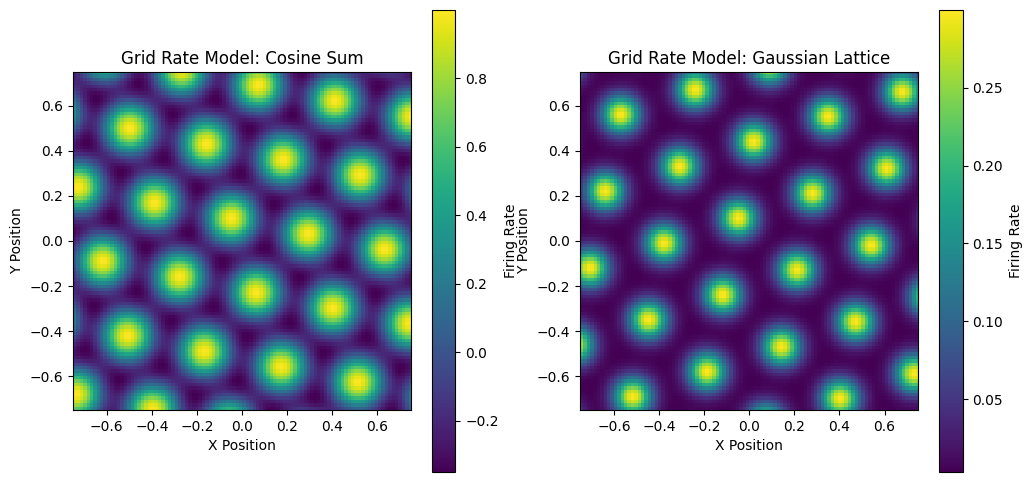

In [263]:
xs = np.linspace(-0.75, 0.75, 100)
ys = np.linspace(-0.75, 0.75, 100)
X, Y = np.meshgrid(xs, ys, indexing="xy")

R_pred_1 = grid_rate_cosine(X, Y, lam=0.35, theta=0.2, phi_x=0.1, phi_y=-0.05, b=0.1, A=0.3)
R_pred_2 = grid_rate_gaussian_lattice(X, Y, lam=0.35, theta=0.2, phi_x=0.1, phi_y=-0.05, b=0.0, a=0.3, sigma=0.06,
                                extent=(-0.75, 0.75, -0.75, 0.75))

plt.subplots(1, 2, figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(R_pred_1.T, origin='lower', extent=[-0.75, 0.75, -0.75, 0.75])
plt.colorbar(label='Firing Rate')
plt.title('Grid Rate Model: Cosine Sum')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.subplot(1, 2, 2)
plt.imshow(R_pred_2.T, origin='lower', extent=[-0.75, 0.75, -0.75, 0.75])
plt.colorbar(label='Firing Rate')
plt.title('Grid Rate Model: Gaussian Lattice')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.show()